In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/Dataset"
!ls

/content/drive/MyDrive/Dataset
UNSW_NB15_testing-set.csv  UNSW_NB15_training-set.csv


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [4]:
def load_data(file_path):
  data = pd.read_csv(file_path)
  return data

train_df = load_data("/content/drive/MyDrive/Dataset/UNSW_NB15_training-set.csv")
test_df = load_data("/content/drive/MyDrive/Dataset/UNSW_NB15_testing-set.csv")

def preprocess(train_df, test_df):
  excluded_cols = ["id", "label", "attack_cat"]

  train_features = train_df.drop(columns=excluded_cols)
  test_features = test_df.drop(columns=excluded_cols)

  categorical_cols = train_features.select_dtypes(include=["object"]).columns.tolist()

  train_labels_text = train_df["attack_cat"]
  test_labels_text = test_df["attack_cat"]

  label_encoder = LabelEncoder()
  train_labels = label_encoder.fit_transform(train_labels_text)
  test_labels = label_encoder.transform(test_labels_text)

  train_features_encoded = pd.get_dummies(train_features, columns=categorical_cols)
  test_features_encoded = pd.get_dummies(test_features, columns=categorical_cols)

  train_features_encoded, test_features_encoded = train_features_encoded.align(
      test_features_encoded,
      join="left",
      axis=1,
      fill_value=0
  )

  train_features_encoded = train_features_encoded.astype(float)
  test_features_encoded = test_features_encoded.astype(float)

  scaler = StandardScaler()
  train_features_scaled = scaler.fit_transform(train_features_encoded)
  test_features_scaled = scaler.transform(test_features_encoded)

  return train_features_scaled, train_labels, test_features_scaled, test_labels, label_encoder

82332
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


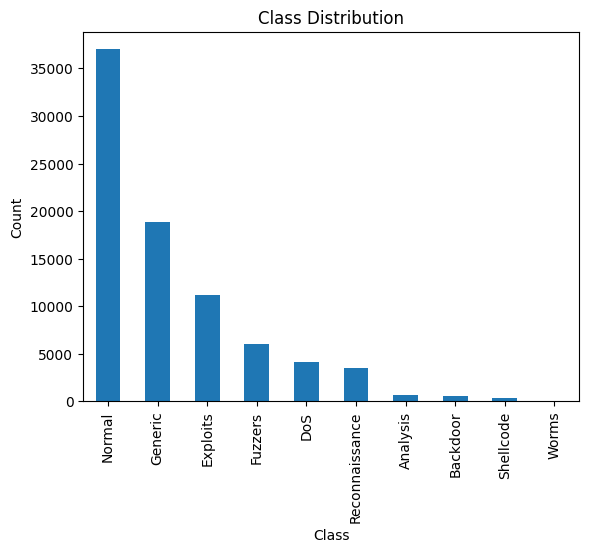

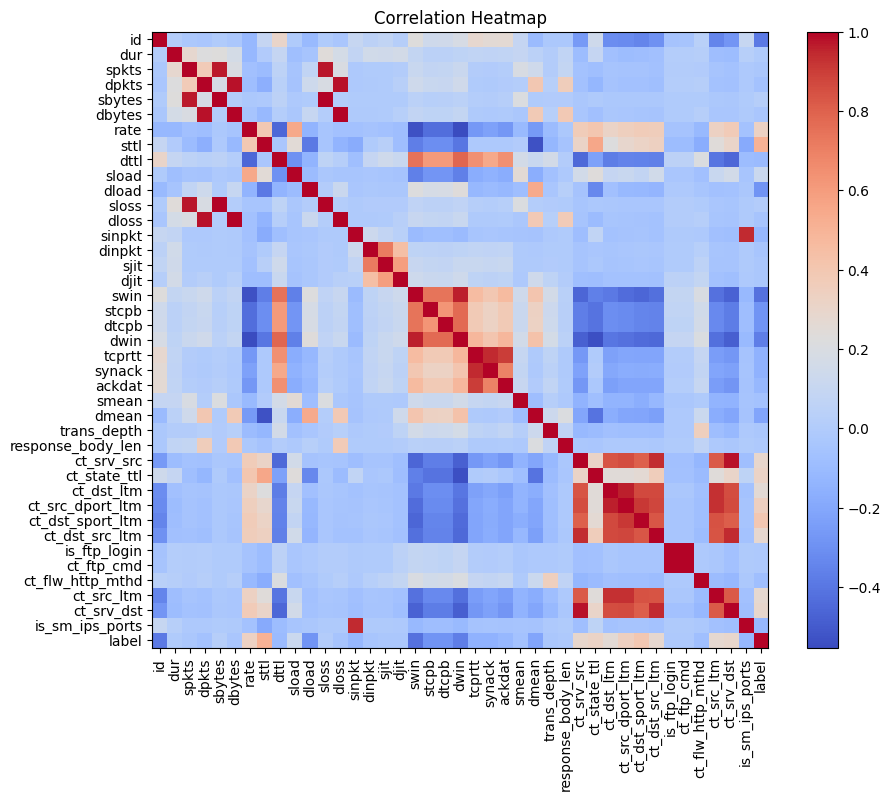

In [ ]:
def dataset_info(df):
  print(len(df))
  print(df["attack_cat"].value_counts())

  df["attack_cat"].value_counts().plot(kind="bar")
  plt.title("Class Distribution")
  plt.xlabel("Class")
  plt.ylabel("Count")

  numeric_df = df.select_dtypes(include=np.number)
  corr_matrix = numeric_df.corr()
  plt.figure(figsize=(10, 8))
  plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest", )
  plt.colorbar()
  plt.title("Correlation Heatmap")
  plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
  plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

  plt.show()


dataset_info(train_df)

In [5]:
def calculate_class_weights(train_labels):
  classes = np.unique(train_labels)

  class_weights = compute_class_weight(
      class_weight="balanced",
      classes=classes,
      y=train_labels
  )

  class_weights = np.sqrt(class_weights)

  class_weights_dict = dict(zip(classes, class_weights))

  return class_weights_dict

In [6]:
def create_validation_split(train_features_scaled, train_labels):
  return train_test_split(
      train_features_scaled,
      train_labels,
      test_size=0.2,
      random_state=42,
      stratify=train_labels
  )

In [15]:
def build_baseline_model(input_dim, num_classes):
  model = Sequential([
      Dense(64, activation="relu", input_shape=(input_dim,)),
      Dense(32, activation="relu"),
      Dense(16, activation="relu"),
      Dense(num_classes, activation="softmax")
  ])

  model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["acc"]
  )

  model.summary()

  return model

In [16]:
def build_paper_dnn_model(input_dim, num_classes):
  model = Sequential([
      Dense(100, activation="relu", input_shape=(input_dim,)),
      Dense(100, activation="relu"),
      Dense(100, activation="relu"),
      Dense(num_classes, activation="softmax")
  ])

  model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["acc"]
  )

  model.summary()

  return model

In [17]:
def build_paper_ann_model(input_dim, num_classes):
  model = Sequential([
      Input(shape=(input_dim,)),
      Dense(850, activation="relu"),
      Dense(num_classes, activation="softmax")
  ])

  model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["acc"]
  )

  model.summary()

  return model

In [18]:
def train_model(model, train_features_final, train_labels_final, validation_features, validation_labels, class_weights_dict, epochs, batch_size):
  history = model.fit(
      train_features_final,
      train_labels_final,
      epochs=epochs,
      batch_size=batch_size,
      validation_data=(validation_features, validation_labels),
      class_weight=class_weights_dict
  )

  return history

In [9]:
def evaluate_model(history, model, test_features_scaled, test_labels):
  acc_train = history.history["acc"]
  loss_train = history.history["loss"]
  acc_val = history.history["val_acc"]
  loss_val = history.history["val_loss"]

  epochs = range(1, len(acc_train) + 1)

  plt.figure()
  plt.ylim(bottom=0)
  plt.plot(epochs, acc_train, "o-", color="blue", label="Train accuracy")
  plt.plot(epochs, acc_val, "s--", color="red", label="Val accuracy")
  plt.title("Train vs Validation Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.legend()

  plt.figure()
  plt.ylim(bottom=0)
  plt.plot(epochs, loss_train, "o-", color="blue", label="Train loss")
  plt.plot(epochs, loss_val, "s--", color="red", label="Val loss")
  plt.title("Train vs Validation Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  plt.show()

  test_loss, test_accuracy = model.evaluate(test_features_scaled, test_labels)

  print("Test accuracy:", test_accuracy)
  print("Test loss:", test_loss)

In [10]:
def predict(model, test_features_scaled):
  predictions = model.predict(test_features_scaled)
  return predictions

def evaluate_predictions(predictions, test_labels, label_encoder):
  label_pred = np.argmax(predictions, axis=1)
  label_true = test_labels

  print("Classification Report:")
  print(classification_report(
      label_true,
      label_pred,
      target_names=label_encoder.classes_
  ))

  cm = confusion_matrix(label_true, label_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal',
 'Reconnaissance', 'Shellcode', 'Worms'])

  disp.plot(cmap=plt.cm.Reds, xticks_rotation=90)
  plt.title("Confusion Matrix")
  plt.show()

In [22]:
def run_experiment(train_df, test_df, model_config, experiment_name, epochs, batch_size):
  print('='*40)
  print(f'Experiment: {experiment_name}')
  print('='*40)

  train_features_scaled, train_labels, test_features_scaled, test_labels, label_encoder = preprocess(train_df, test_df)
  train_features_final, validation_features, train_labels_final, validation_labels = create_validation_split(train_features_scaled, train_labels)
  class_weights_dict = calculate_class_weights(train_labels_final)

  input_dim = train_features_scaled.shape[1]
  num_classes = len(label_encoder.classes_)
  model = model_config(input_dim, num_classes)

  history = train_model(model, train_features_final, train_labels_final, validation_features, validation_labels, class_weights_dict, epochs, batch_size)
  evaluate_model(history, model, test_features_scaled, test_labels)
  predictions = predict(model, test_features_scaled)
  evaluate_predictions(predictions, test_labels, label_encoder)

  return model, history

Experiment: Baseline


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │        12,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,002 (58.60 KB)

 Trainable params: 15,002 (58.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.7333 - loss: 0.8728 - val_acc: 0.7782 - val_loss: 0.6162
Epoch 2/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.7917 - loss: 0.6612 - val_acc: 0.8136 - val_loss: 0.5386
Epoch 3/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8113 - loss: 0.6190 - val_acc: 0.8183 - val_loss: 0.5063
Epoch 4/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8162 - loss: 0.5972 - val_acc: 0.8264 - val_loss: 0.4882
Epoch 5/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.8218 - loss: 0.5808 - val_acc: 0.8241 - val_loss: 0.4904
Epoch 6/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8246 - loss: 0.5696 - val_acc: 0.8204 - val_loss: 0.4879
Epoch 7/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8274 - loss: 0.5589 - val_acc: 0.8232 - val_loss: 0.4740
Epoch 8/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8292 - loss: 0.5507 - val_acc: 0.8284 - val_loss: 0.4580
Epoch 9/10
1030/1030 ━━━━━━━━━━━━━━━━━━

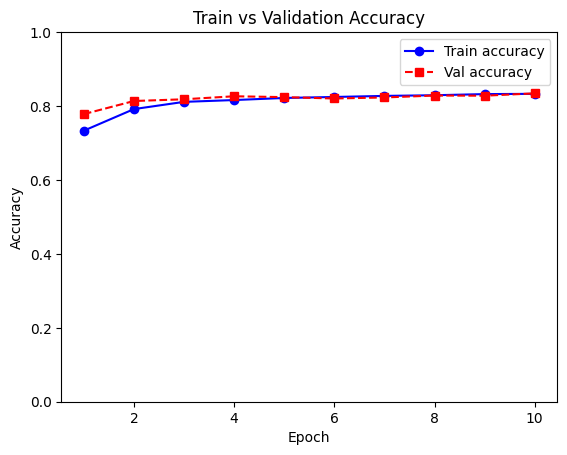

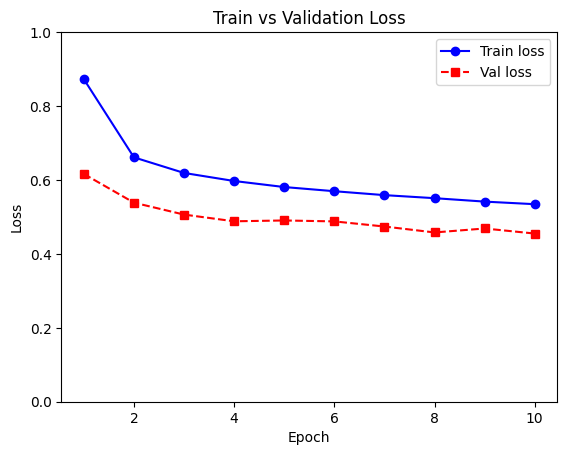

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - acc: 0.7409 - loss: 0.6918
Test accuracy: 0.7409448027610779
Test loss: 0.6917967796325684
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Classification Report:
                precision    recall  f1-score   support

      Analysis       0.05      0.03      0.04      2000
      Backdoor       0.04      0.00      0.01      1746
           DoS       0.33      0.77      0.46     12264
      Exploits       0.78      0.52      0.62     33393
       Fuzzers       0.60      0.14      0.22     18184
       Generic       1.00      0.98      0.99     40000
        Normal       0.78      0.97      0.86     56000
Reconnaissance       0.72      0.68      0.70     10491
     Shellcode       0.49      0.24      0.32      1133
         Worms       0.45      0.15      0.22       130

      accuracy                           0.74    175341
     macro avg       0.52      0.45      0.44    175341
  weighted avg       0.76      0.74      0.72    175341



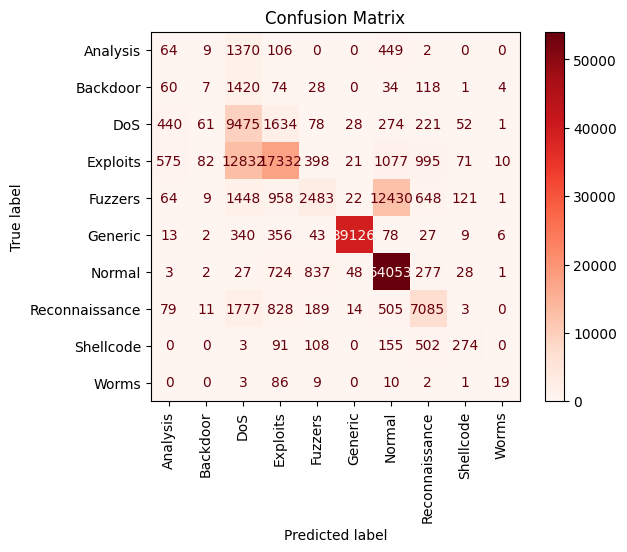

(<Sequential name=sequential_3, built=True>,
 <keras.src.callbacks.history.History at 0x7860974fb170>)

In [23]:
# baseline model
run_experiment(train_df, test_df, build_baseline_model, "Baseline", 10, 64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        19,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,310 (157.46 KB)

 Trainable params: 40,310 (157.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.7566 - loss: 0.8045 - val_acc: 0.8056 - val_loss: 0.5567
Epoch 2/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8066 - loss: 0.6273 - val_acc: 0.8107 - val_loss: 0.4979
Epoch 3/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8174 - loss: 0.5874 - val_acc: 0.8240 - val_loss: 0.4856
Epoch 4/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.8244 - loss: 0.5644 - val_acc: 0.8308 - val_loss: 0.4554
Epoch 5/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8298 - loss: 0.5482 - val_acc: 0.8202 - val_loss: 0.4781
Epoch 6/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8324 - loss: 0.5349 - val_acc: 0.8335 - val_loss: 0.4405
Epoch 7/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8346 - loss: 0.5253 - val_acc: 0.8349 - val_loss: 0.4394
Epoch 8/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8348 - loss: 0.5161 - val_acc: 0.8416 - val_loss: 0.4281
Epoch 9/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/

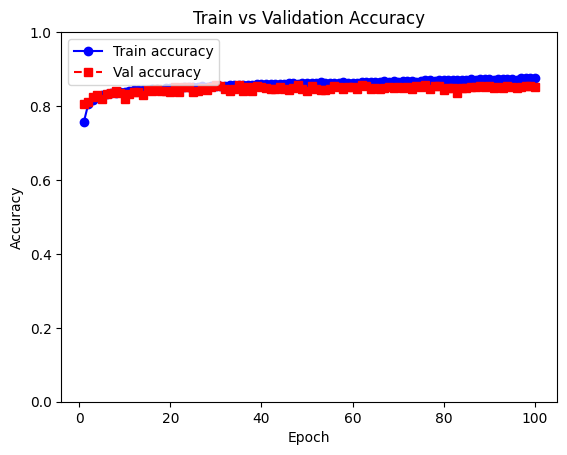

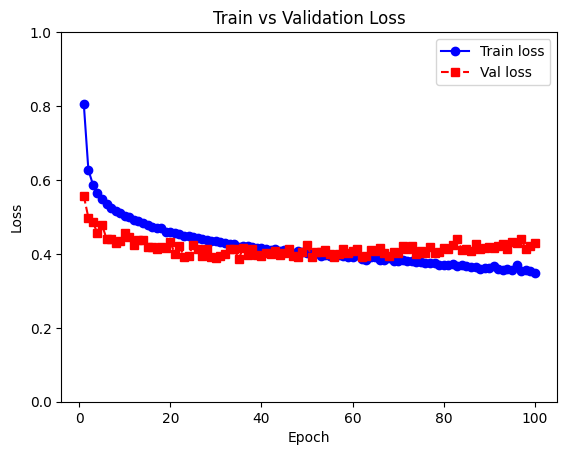

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - acc: 0.7460 - loss: 1.1996
Test accuracy: 0.7460434436798096
Test loss: 1.1995954513549805
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Classification Report:
                precision    recall  f1-score   support

      Analysis       0.05      0.01      0.02      2000
      Backdoor       0.09      0.06      0.08      1746
           DoS       0.33      0.77      0.46     12264
      Exploits       0.82      0.50      0.62     33393
       Fuzzers       0.67      0.18      0.28     18184
       Generic       0.98      0.98      0.98     40000
        Normal       0.78      0.96      0.86     56000
Reconnaissance       0.85      0.70      0.77     10491
     Shellcode       0.53      0.52      0.52      1133
         Worms       0.20      0.28      0.23       130

      accuracy                           0.75    175341
     macro avg       0.53      0.50      0.48    175341
  weighted avg       0.78      0.75      0.73    175341



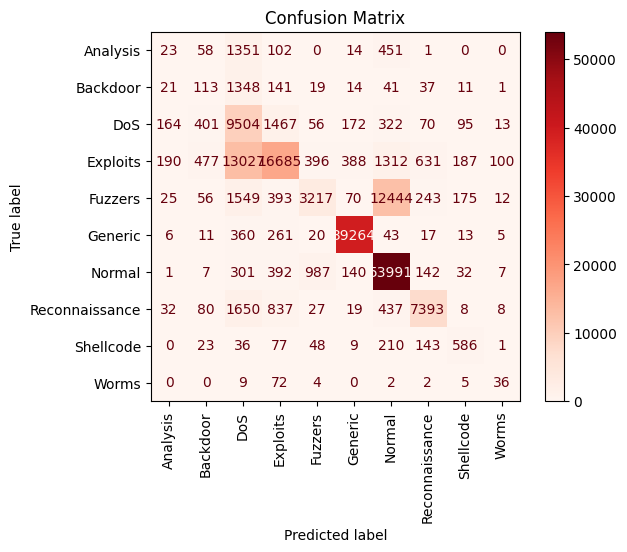

In [12]:
# Paper DNN based model
run_experiment(train_df, test_df)
#run_experiment(train_df, test_df, build_paper_dnn_model, "Paper based DNN", 100, 100)

Experiment: Paper based ANN


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 850)            │       162,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         8,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,860 (667.42 KB)

 Trainable params: 170,860 (667.42 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.7661 - loss: 0.8688 - val_acc: 0.8037 - val_loss: 0.6330
Epoch 2/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - acc: 0.8050 - loss: 0.6980 - val_acc: 0.8127 - val_loss: 0.5583
Epoch 3/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - acc: 0.8133 - loss: 0.6533 - val_acc: 0.8099 - val_loss: 0.5736
Epoch 4/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - acc: 0.8175 - loss: 0.6352 - val_acc: 0.8048 - val_loss: 0.5776
Epoch 5/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - acc: 0.8215 - loss: 0.6133 - val_acc: 0.8165 - val_loss: 0.5378
Epoch 6/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - acc: 0.8238 - loss: 0.6025 - val_acc: 0.8170 - val_loss: 0.5220
Epoch 7/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - acc: 0.8265 - loss: 0.5872 - val_acc: 0.8294 - val_loss: 0.4864
Epoch 8/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - acc: 0.8297 - loss: 0.5740 - val_acc: 0.8243 - val_loss: 0.4969
Epoch 9/100
659/659 ━━━━━━━━━━━━━━━━━━━━ 5s 7m

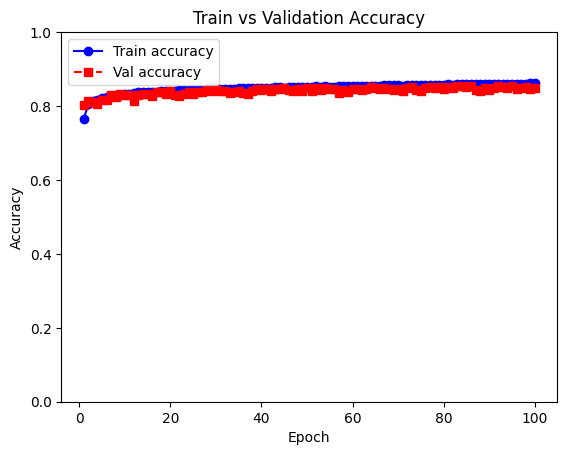

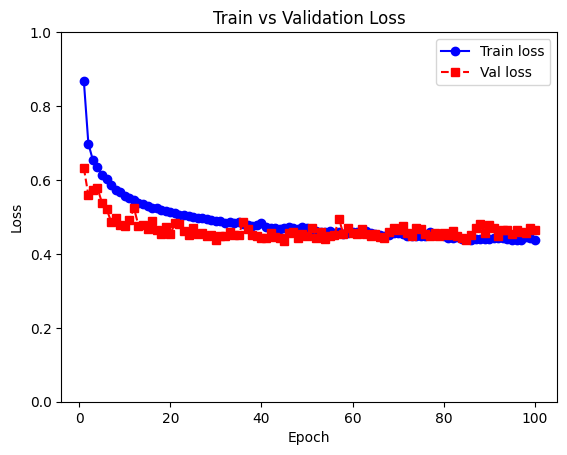

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - acc: 0.7358 - loss: 1.3150
Test accuracy: 0.7358461618423462
Test loss: 1.3150101900100708
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
Classification Report:
                precision    recall  f1-score   support

      Analysis       0.05      0.02      0.03      2000
      Backdoor       0.07      0.03      0.04      1746
           DoS       0.33      0.66      0.44     12264
      Exploits       0.82      0.47      0.60     33393
       Fuzzers       0.65      0.16      0.26     18184
       Generic       0.96      0.98      0.97     40000
        Normal       0.76      0.97      0.86     56000
Reconnaissance       0.70      0.74      0.72     10491
     Shellcode       0.40      0.55      0.47      1133
         Worms       0.07      0.38      0.12       130

      accuracy                           0.74    175341
     macro avg       0.48      0.50      0.45    175341
  weighted avg       0.76      0.74      0.71    175341



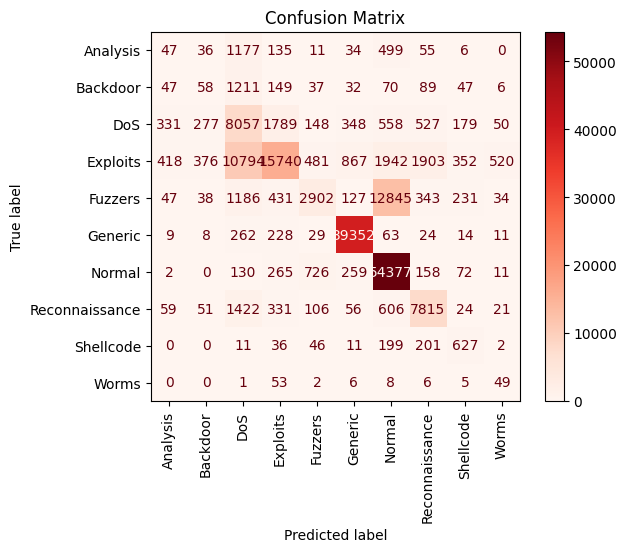

(<Sequential name=sequential_4, built=True>,
 <keras.src.callbacks.history.History at 0x78609f8b3fb0>)

In [24]:
# Paper ANN based model
run_experiment(train_df, test_df, build_paper_ann_model, "Paper based ANN", 100, 100)